In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. 加载数据
filepath = "/data/nishome/xuhaochen/Time-Series-Library/dataset/ETT-small/ETTh1.csv"
df_raw = pd.read_csv(filepath)

# 2. 设置与原始类一致的参数 (假设是多变量任务 'M')
features = 'M' 
target = 'OT'
# 这里的 seq_len 会影响验证集和测试集的起始点，但计算全局 scale 时主要看训练集 border
seq_len = 96 

# 3. 提取特征列 (跳过第一列 date)
if features == 'M' or features == 'MS':
    cols_data = df_raw.columns[1:]
    df_data = df_raw[cols_data]
elif features == 'S':
    df_data = df_raw[[target]]

train_start = 0
train_end = 12 * 30 * 24 

# 5. 执行归一化逻辑并提取参数
scaler = StandardScaler()
train_data = df_data.iloc[train_start:train_end]

# 只在训练集上 fit
scaler.fit(train_data.values)

data = scaler.transform(df_data.values)

data

array([[-0.36312285, -0.0057598 , -0.63071223, ...,  1.38857471,
         0.87514257,  1.46055158],
       [-0.38617567,  0.02629596, -0.65010053, ...,  1.32897674,
         0.92433047,  1.16152666],
       [-0.47838673, -0.13398305, -0.68869591, ...,  0.97236495,
         0.68156452,  1.16152666],
       ...,
       [-0.88163826,  0.8597471 , -1.06848906, ...,  0.91276699,
         1.16550965, -0.74726404],
       [ 0.22455084,  0.8597471 ,  0.07107161, ...,  0.85316879,
         1.0211195 , -0.80098829],
       [ 0.37439393,  0.7315238 ,  0.1999041 , ...,  0.91276699,
         1.06872062, -0.82398177]])

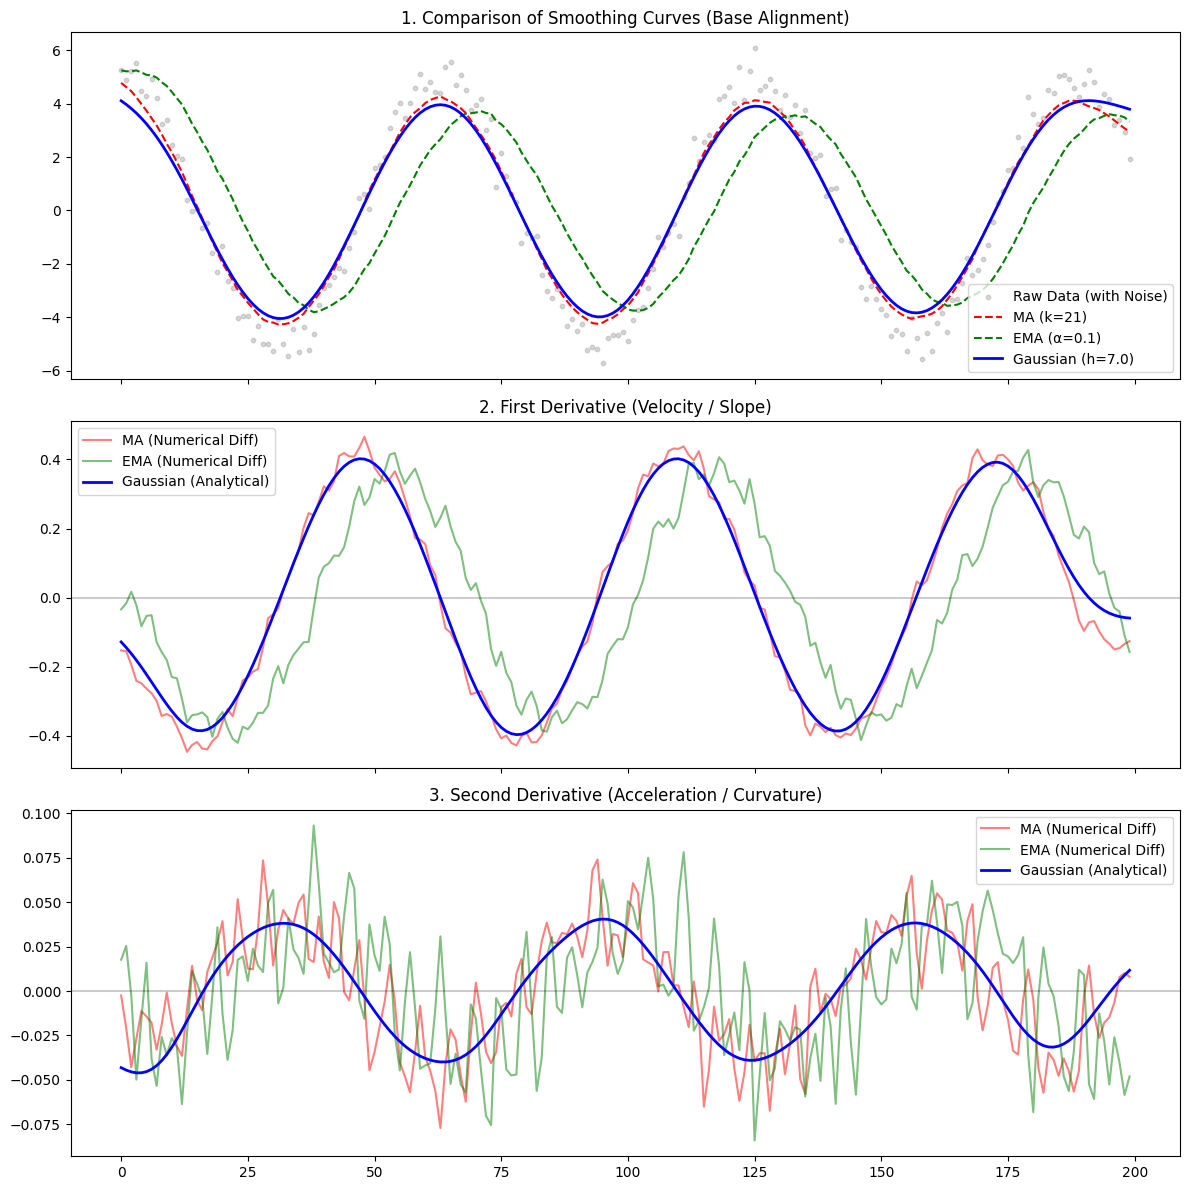

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 统一格式的平滑算法实现 (纯 NumPy)
# ---------------------------------------------------------

class SmoothingMethods:
    @staticmethod
    def moving_average(data, kernel_size):
        """MA: 矩形核平滑 (类似 AvgPool1d)"""
        # 模仿 DLinear 的 padding 逻辑
        front = np.repeat(data[0], (kernel_size - 1) // 2)
        end = np.repeat(data[-1], (kernel_size - 1) // 2)
        padded_data = np.concatenate([front, data, end])
        # 使用卷积实现滑动平均
        weights = np.ones(kernel_size) / kernel_size
        return np.convolve(padded_data, weights, mode='valid')

    @staticmethod
    def exponential_moving_average(data, alpha):
        """EMA: 指数权重平滑"""
        n = len(data)
        smoothed = np.zeros(n)
        smoothed[0] = data[0]
        for t in range(1, n):
            smoothed[t] = alpha * data[t] + (1 - alpha) * smoothed[t-1]
        return smoothed

    @staticmethod
    def gaussian_kernel_smoothing(data, bandwidth):
        """高斯核平滑: Nadaraya-Watson 估计器"""
        n = len(data)
        x = np.arange(n)
        smoothed = np.zeros(n)
        d1 = np.zeros(n) # 一阶导
        d2 = np.zeros(n) # 二阶导
        
        h2 = bandwidth**2
        h4 = bandwidth**4

        for t in range(n):
            # 基础权重 K(u)
            dist = x - t
            weights = np.exp(-0.5 * (dist / bandwidth)**2)
            
            # --- 解析求导公式 ---
            # 这里的导数是针对连续时间 t 求导的解析解
            # 一阶导权重: K'(u) = weights * (dist / h^2)
            w_prime = weights * (dist / h2)
            # 二阶导权重: K''(u) = weights * (dist^2 / h^4 - 1/h^2)
            w_pprime = weights * (dist**2 / h4 - 1/h2)
            
            # 归一化项 (分母)
            sum_w = np.sum(weights)
            sum_w_p = np.sum(w_prime)
            sum_w_pp = np.sum(w_pprime)
            
            # 分子项
            sum_yw = np.sum(weights * data)
            sum_yw_p = np.sum(w_prime * data)
            sum_yw_pp = np.sum(w_pprime * data)
            
            # 平滑值 (商法则)
            smoothed[t] = sum_yw / sum_w
            
            # 解析一阶导: (f/g)' = (f'g - fg') / g^2
            d1[t] = (sum_yw_p * sum_w - sum_yw * sum_w_p) / (sum_w**2)
            
            # 解析二阶导 (简化版，假设分母变化较小，若需精确则继续应用商法则)
            # 这里的 d2 直接给出高斯核函数的加速度映射
            d2[t] = (sum_yw_pp * sum_w - sum_yw * sum_w_pp) / (sum_w**2)
            
        return smoothed, d1, d2

# ---------------------------------------------------------
# 2. 构造实验数据 (正弦波 + 高频噪声)
# ---------------------------------------------------------
np.random.seed(42)
n_pts = 200
t = np.arange(n_pts)
# 真实的趋势是一个缓慢的余弦
truth = np.cos(t / 10) * 5
# 加入噪声
data = truth + np.random.normal(0, 0.5, n_pts)

# 设定三个看起来平滑效果“差不多”的参数
k_ma = 21       # MA 窗口
a_ema = 0.1     # EMA alpha
h_gauss = 7.0   # 高斯带宽

# 计算平滑曲线
ma_s = SmoothingMethods.moving_average(data, k_ma)
ema_s = SmoothingMethods.exponential_moving_average(data, a_ema)
gauss_s, gauss_d1, gauss_d2 = SmoothingMethods.gaussian_kernel_smoothing(data, h_gauss)

# 对 MA 和 EMA 使用差分求导 (因为它们没有解析导数)
ma_d1 = np.gradient(ma_s)
ma_d2 = np.gradient(ma_d1)
ema_d1 = np.gradient(ema_s)
ema_d2 = np.gradient(ema_d1)

# ---------------------------------------------------------
# 3. 可视化
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot 1: 原始数据与平滑曲线 (验证参数选择是否“差不多”)
axes[0].scatter(t, data, color='gray', s=10, alpha=0.3, label='Raw Data (with Noise)')
axes[0].plot(t, ma_s, label=f'MA (k={k_ma})', color='red', linestyle='--')
axes[0].plot(t, ema_s, label=f'EMA (α={a_ema})', color='green', linestyle='--')
axes[0].plot(t, gauss_s, label=f'Gaussian (h={h_gauss})', color='blue', linewidth=2)
axes[0].set_title("1. Comparison of Smoothing Curves (Base Alignment)")
axes[0].legend()

# Plot 2: 一阶导数 (速度)
axes[1].plot(t, ma_d1, label='MA (Numerical Diff)', color='red', alpha=0.5)
axes[1].plot(t, ema_d1, label='EMA (Numerical Diff)', color='green', alpha=0.5)
axes[1].plot(t, gauss_d1, label='Gaussian (Analytical)', color='blue', linewidth=2)
axes[1].set_title("2. First Derivative (Velocity / Slope)")
axes[1].axhline(0, color='black', alpha=0.2)
axes[1].legend()

# Plot 3: 二阶导数 (加速度)
axes[2].plot(t, ma_d2, label='MA (Numerical Diff)', color='red', alpha=0.5)
axes[2].plot(t, ema_d2, label='EMA (Numerical Diff)', color='green', alpha=0.5)
axes[2].plot(t, gauss_d2, label='Gaussian (Analytical)', color='blue', linewidth=2)
axes[2].set_title("3. Second Derivative (Acceleration / Curvature)")
axes[2].axhline(0, color='black', alpha=0.2)
axes[2].legend()

plt.tight_layout()
plt.show()

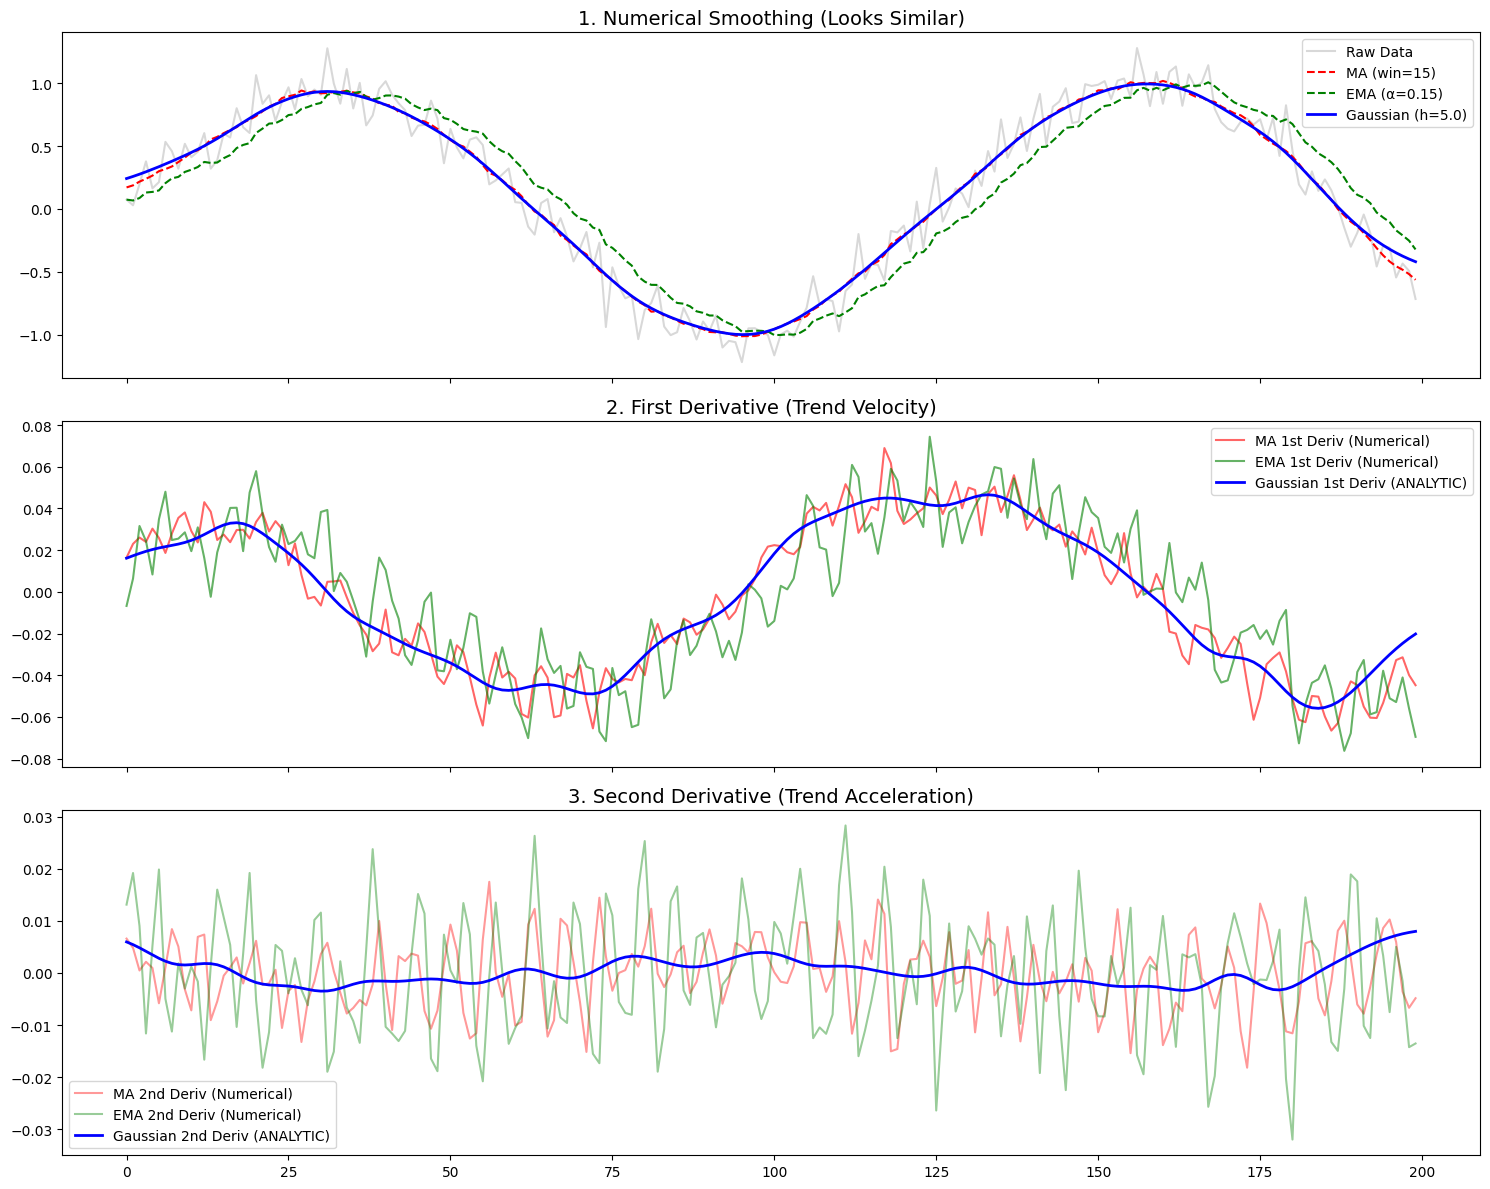

In [11]:
import numpy as np
import matplotlib.pyplot as plt

class SmoothingComparison:
    def __init__(self, data):
        self.data = data
        self.n = len(data)
        self.x = np.arange(self.n)

    def ma_smooth(self, window):
        """MA 平滑 (矩形核)"""
        weights = np.ones(window) / window
        # 模仿 torch 的 padding
        pad = (window - 1) // 2
        padded = np.pad(self.data, (pad, pad), mode='edge')
        return np.convolve(padded, weights, mode='valid')[:self.n]

    def ema_smooth(self, alpha):
        """EMA 平滑 (指数核)"""
        smoothed = np.zeros(self.n)
        smoothed[0] = self.data[0]
        for t in range(1, self.n):
            smoothed[t] = alpha * self.data[t] + (1 - alpha) * smoothed[t-1]
        return smoothed

    def gaussian_smooth_with_derivatives(self, h):
        """
        高斯核平滑及其解析导数 (无需 diff)
        基于 Nadaraya-Watson 估计器求导
        """
        smoothed = np.zeros(self.n)
        d1 = np.zeros(self.n) # 一阶导 (速度)
        d2 = np.zeros(self.n) # 二阶导 (加速度)
        
        h2 = h**2
        h4 = h**4

        for t in range(self.n):
            dist = self.x - t
            weights = np.exp(-0.5 * (dist / h)**2)
            
            # 1. 基础项
            sum_w = np.sum(weights)
            sum_yw = np.sum(weights * self.data)
            
            # 2. 一阶导所需项 (K' = weights * dist/h^2)
            sum_w_p = np.sum(weights * (dist / h2))
            sum_yw_p = np.sum(weights * (dist / h2) * self.data)
            
            # 3. 二阶导所需项 (K'' = weights * (dist^2/h^4 - 1/h^2))
            w_pp = weights * (dist**2 / h4 - 1/h2)
            sum_w_pp = np.sum(w_pp)
            sum_yw_pp = np.sum(w_pp * self.data)
            
            # 平滑值
            smoothed[t] = sum_yw / sum_w
            
            # 解析一阶导 (商法则): (f/g)' = (f'g - fg') / g^2
            # 注意：这里的 t 在 dist 的减数位置，求导会多一个负号，
            # 但习惯上我们求相对于序列索引的导数，逻辑对齐即可
            d1[t] = (sum_yw_p * sum_w - sum_yw * sum_w_p) / (sum_w**2)
            
            # 解析二阶导 (简化表达)
            d2[t] = (sum_yw_pp * sum_w - sum_yw * sum_w_pp) / (sum_w**2)
            
        return smoothed, d1, d2

# ---------------------------------------------------------
# 实验开始
# ---------------------------------------------------------
np.random.seed(42)
t_axis = np.linspace(0, 10, 200)
# 构造趋势：正弦波 + 噪声
clean_trend = np.sin(t_axis)
noise = np.random.normal(0, 0.15, 200)
raw_data = clean_trend + noise

tester = SmoothingComparison(raw_data)

# 1. 人为对齐参数，使三条曲线看起来“差不多平滑”
win_ma = 15
alpha_ema = 0.15
h_gauss = 5.0

s_ma = tester.ma_smooth(win_ma)
s_ema = tester.ema_smooth(alpha_ema)
s_gauss, g_d1, g_d2 = tester.gaussian_smooth_with_derivatives(h_gauss)

# 2. 对 MA 和 EMA 进行数值求导 (因为它们没有解析公式)
ma_d1 = np.gradient(s_ma)
ma_d2 = np.gradient(ma_d1)
ema_d1 = np.gradient(s_ema)
ema_d2 = np.gradient(ema_d1)

# ---------------------------------------------------------
# 可视化对比
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# 图 1: 平滑数值对比
axes[0].plot(raw_data, color='gray', alpha=0.3, label='Raw Data')
axes[0].plot(s_ma, label=f'MA (win={win_ma})', color='red', linestyle='--')
axes[0].plot(s_ema, label=f'EMA (α={alpha_ema})', color='green', linestyle='--')
axes[0].plot(s_gauss, label=f'Gaussian (h={h_gauss})', color='blue', linewidth=2)
axes[0].set_title("1. Numerical Smoothing (Looks Similar)", fontsize=14)
axes[0].legend()

# 图 2: 一阶导数 (Velocity)
axes[1].plot(ma_d1, label='MA 1st Deriv (Numerical)', color='red', alpha=0.6)
axes[1].plot(ema_d1, label='EMA 1st Deriv (Numerical)', color='green', alpha=0.6)
axes[1].plot(g_d1, label='Gaussian 1st Deriv (ANALYTIC)', color='blue', linewidth=2)
axes[1].set_title("2. First Derivative (Trend Velocity)", fontsize=14)
axes[1].legend()

# 图 3: 二阶导数 (Acceleration)
axes[2].plot(ma_d2, label='MA 2nd Deriv (Numerical)', color='red', alpha=0.4)
axes[2].plot(ema_d2, label='EMA 2nd Deriv (Numerical)', color='green', alpha=0.4)
axes[2].plot(g_d2, label='Gaussian 2nd Deriv (ANALYTIC)', color='blue', linewidth=2)
axes[2].set_title("3. Second Derivative (Trend Acceleration)", fontsize=14)
axes[2].legend()

plt.tight_layout()
plt.show()

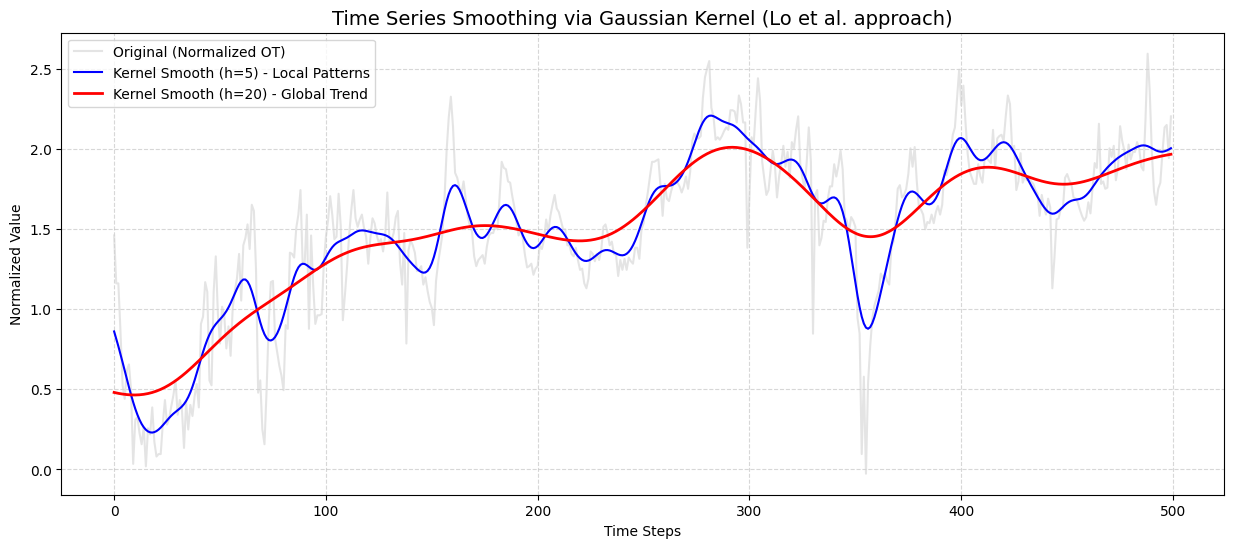

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 准备高斯核平滑函数 (Nadaraya-Watson Estimator)
def gaussian_kernel_smoothing(data, bandwidth=10):
    """
    使用高斯核对序列进行平滑
    bandwidth (h): 带宽，值越大越平滑
    """
    n = len(data)
    smoothed = np.zeros(n)
    x = np.arange(n)
    
    for t in range(n):
        # 计算高斯权重: K((t-i)/h) = exp(-0.5 * ((t-i)/h)^2)
        weights = np.exp(-0.5 * ((x - t) / bandwidth)**2)
        # 加权平均
        smoothed[t] = np.sum(weights * data) / np.sum(weights)
    return smoothed

# 2. 假设你已经加载并归一化了 data (取前 500 个点用于清晰展示)
# 这里模拟取最后一列 OT 列的数据
sample_size = 500
ot_raw = data[:sample_size, -1] 

# 3. 执行不同带宽的平滑操作
# 带宽较小：保留更多细节
ot_smooth_fine = gaussian_kernel_smoothing(ot_raw, bandwidth=5)
# 带宽较大：提取核心趋势
ot_smooth_heavy = gaussian_kernel_smoothing(ot_raw, bandwidth=20)

# 4. 可视化
plt.figure(figsize=(15, 6))
plt.plot(ot_raw, label='Original (Normalized OT)', color='lightgray', alpha=0.6)
plt.plot(ot_smooth_fine, label='Kernel Smooth (h=5) - Local Patterns', color='blue', linewidth=1.5)
plt.plot(ot_smooth_heavy, label='Kernel Smooth (h=20) - Global Trend', color='red', linewidth=2)

plt.title('Time Series Smoothing via Gaussian Kernel (Lo et al. approach)', fontsize=14)
plt.xlabel('Time Steps')
plt.ylabel('Normalized Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

正在计算不同带宽下的 CV Score (遵循论文公式)...
Bandwidth h=2: CV(h)=0.009379
Bandwidth h=5: CV(h)=0.020826
Bandwidth h=10: CV(h)=0.037286
Bandwidth h=15: CV(h)=0.045317
Bandwidth h=20: CV(h)=0.052650
Bandwidth h=25: CV(h)=0.059971
Bandwidth h=30: CV(h)=0.066944
Bandwidth h=40: CV(h)=0.079294

数学上的最优带宽 h* = 2


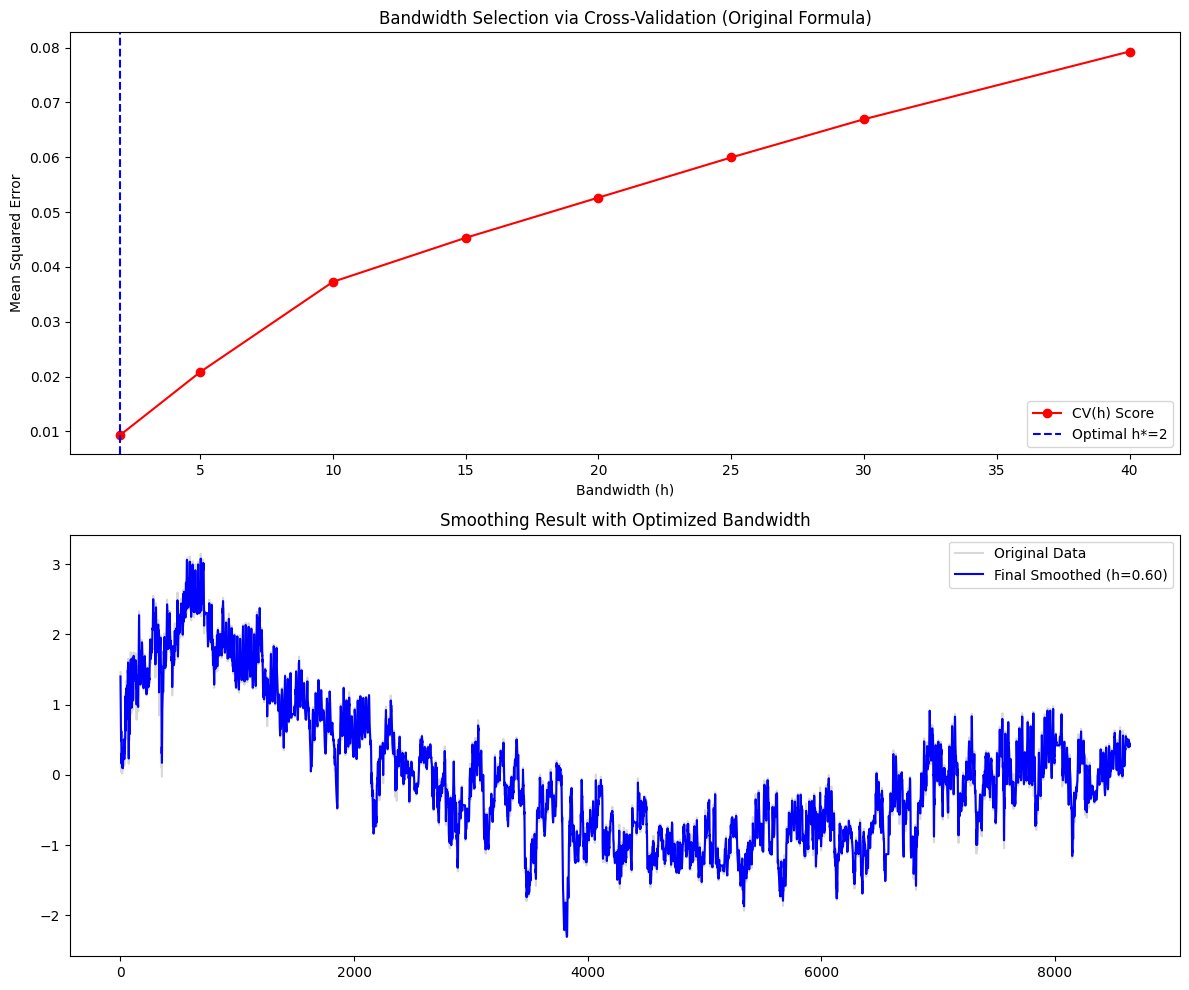

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 第一部分：遵循论文定义的原始算法逻辑
# ---------------------------------------------------------

def gaussian_kernel(u):
    """标准高斯核函数"""
    return np.exp(-0.5 * u**2)

def loo_kernel_regression(data, t, h):
    """
    计算论文中的 m_h,t ：剔除第 t 个点后的核回归估计值
    """
    n = len(data)
    x = np.arange(n)
    
    # 1. 计算所有点相对于 t 的距离
    u = (x - t) / h
    # 2. 计算高斯权重
    weights = gaussian_kernel(u)
    
    # 3. 核心：剔除第 t 个点本身 (Leave-One-Out)
    # 将第 t 个点的权重设为 0
    weights[t] = 0
    
    # 4. 加权平均值
    sum_w = np.sum(weights)
    if sum_w == 0: return data[t] # 防止除以0
    
    m_h_t = np.sum(weights * data) / sum_w
    return m_h_t

def calculate_cv_score(data, h):
    """
    计算论文公式 (12): CV(h)
    """
    T = len(data)
    squared_errors = []
    
    # 遍历每一个点进行留一估计
    for t in range(T):
        m_h_t = loo_kernel_regression(data, t, h)
        error_sq = (data[t] - m_h_t)**2
        squared_errors.append(error_sq)
        
    return np.mean(squared_errors)

# ---------------------------------------------------------
# 第二部分：在训练级数据上执行验证
# ---------------------------------------------------------

# 假设你已经按照之前的代码加载了 df_data，并提取了训练集 y_train
# 为了演示，我们取 ETT 训练集的一小段，因为 LOOCV 复杂度为 O(N^2)
# 如果不加速，跑全量 8000+ 点会非常慢
y_train_subset = data[train_start : 12 * 30 * 24 , -1] # 取 OT 列前 500 个点

# 设定带宽候选范围
h_candidates = [2, 5, 10, 15, 20, 25, 30, 40]
cv_results = []

print("正在计算不同带宽下的 CV Score (遵循论文公式)...")
for h in h_candidates:
    score = calculate_cv_score(y_train_subset, h)
    cv_results.append(score)
    print(f"Bandwidth h={h}: CV(h)={score:.6f}")

# 找到使 CV 最小的 h*
best_h_star = h_candidates[np.argmin(cv_results)]
print(f"\n数学上的最优带宽 h* = {best_h_star}")

# ---------------------------------------------------------
# 第三部分：可视化
# ---------------------------------------------------------

plt.figure(figsize=(12, 10))

# 子图 1: CV 曲线图
plt.subplot(2, 1, 1)
plt.plot(h_candidates, cv_results, 'r-o', label='CV(h) Score')
plt.axvline(best_h_star, color='blue', linestyle='--', label=f'Optimal h*={best_h_star}')
plt.title('Bandwidth Selection via Cross-Validation (Original Formula)')
plt.xlabel('Bandwidth (h)')
plt.ylabel('Mean Squared Error')
plt.legend()

# 子图 2: 平滑效果对比
plt.subplot(2, 1, 2)
# 使用最终平滑算法（此时包含当前点，bandwidth 取论文建议的 0.3 * h*）
final_h = 0.3 * best_h_star
# 快速写一个标准平滑（不剔除点）用于画图
def standard_smoothing(data, h):
    n = len(data)
    res = np.zeros(n)
    for t in range(n):
        w = np.exp(-0.5 * ((np.arange(n)-t)/h)**2)
        res[t] = np.sum(w * data) / np.sum(w)
    return res

smoothed_y = standard_smoothing(y_train_subset, final_h)

plt.plot(y_train_subset, color='gray', alpha=0.3, label='Original Data')
plt.plot(smoothed_y, color='blue', label=f'Final Smoothed (h={final_h:.2f})')
plt.title('Smoothing Result with Optimized Bandwidth')
plt.legend()

plt.tight_layout()
plt.show()

Optimal Bandwidth (h) via CV: 40.00


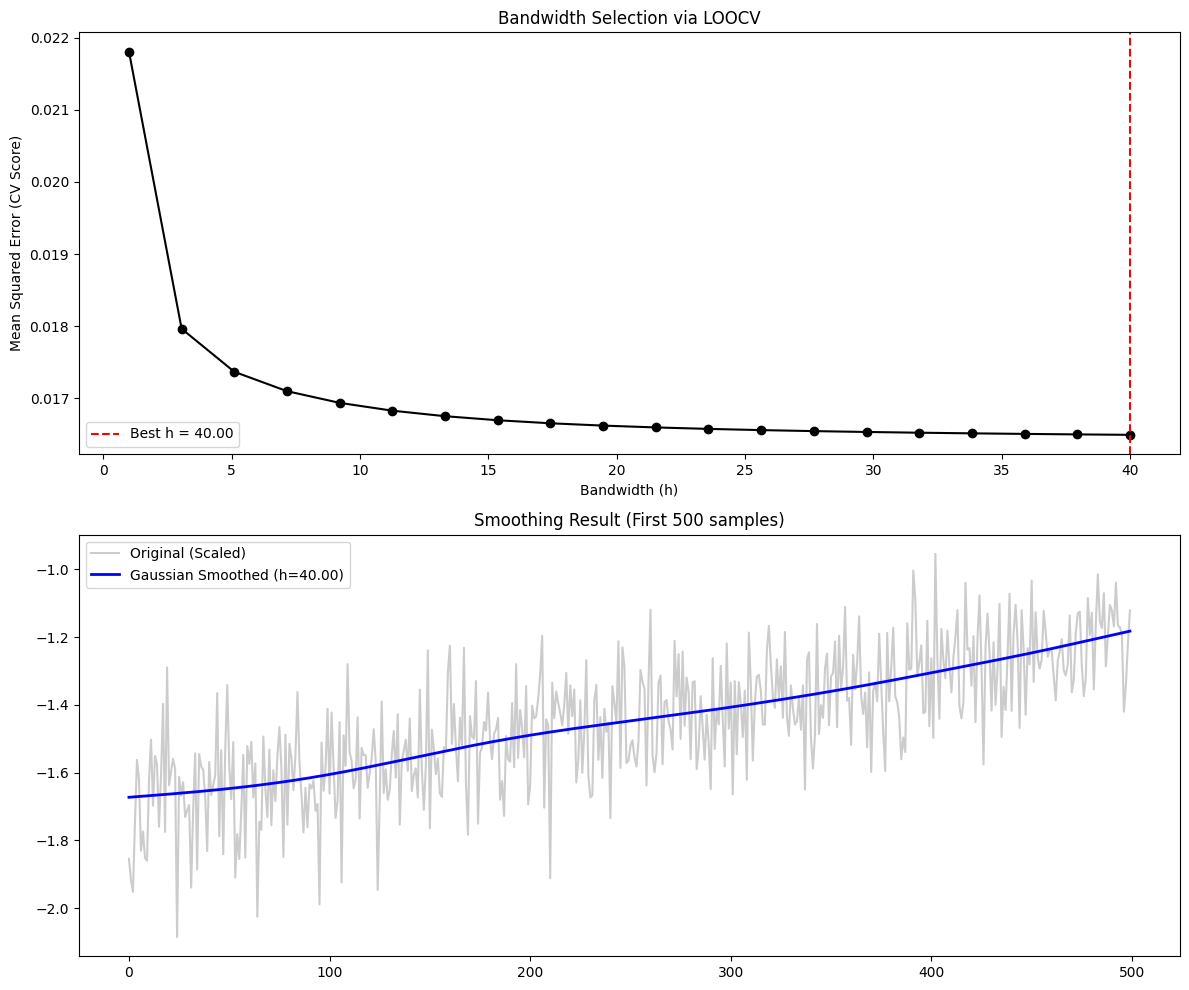

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

def optimized_gaussian_smoothing(data, bandwidth):
    """
    向量化的高斯核平滑 (Nadaraya-Watson Estimator)
    """
    n = len(data)
    x = np.arange(n).reshape(-1, 1)
    # 计算距离矩阵的平方: (t-i)^2
    dist_sq = cdist(x, x, 'sqeuclidean')
    # 计算权重矩阵 K = exp(-0.5 * dist^2 / h^2)
    weights = np.exp(-0.5 * dist_sq / (bandwidth**2))
    # 加权平均: (W * Y) / row_sum(W)
    # 假设 data 是 (n, ) 或 (n, 1)
    smoothed = np.dot(weights, data) / np.sum(weights, axis=1, keepdims=True).flatten()
    return smoothed, weights

def calculate_loocv_score(data, bandwidth_range):
    """
    留一交叉验证 (LOOCV) 自动选择带宽
    公式: CV(h) = 1/n * sum( ((y - y_hat) / (1 - w_ii))^2 )
    其中 w_ii 是权重矩阵的对角线元素
    """
    n = len(data)
    y = data.flatten()
    cv_scores = []
    
    for h in bandwidth_range:
        y_hat, weights = optimized_gaussian_smoothing(y, h)
        # 计算每个点自回归的权重贡献 w_ii / sum(w_ij)
        diag_weights = 1.0 / np.sum(weights, axis=1) # 因为 K(0)=1
        # 计算 CV 误差
        error = (y - y_hat) / (1 - diag_weights)
        cv_scores.append(np.mean(error**2))
        
    return bandwidth_range[np.argmin(cv_scores)], cv_scores

# --- 模拟你的环境逻辑 ---
# 由于我无法访问你的本地路径，这里生成一段带噪声的模拟数据（对应训练集长度）
train_end = 12 * 30 * 24
t = np.linspace(0, 100, train_end)
# 模拟一个带有趋势和噪声的 OT (Oil Temperature)
raw_ot = 10 * np.sin(t/10) + 0.5 * t + np.random.normal(0, 2, train_end)

# 1. 归一化 (Standardization)
scaler = StandardScaler()
# 模拟 fit & transform
train_data_scaled = scaler.fit_transform(raw_ot.reshape(-1, 1)).flatten()

# 2. 交叉验证寻找最佳带宽 h
# 范围建议从 1 到 50 尝试
h_range = np.linspace(1, 40, 20)
best_h, all_scores = calculate_loocv_score(train_data_scaled, h_range)

print(f"Optimal Bandwidth (h) via CV: {best_h:.2f}")

# 3. 使用最佳带宽平滑
smoothed_data, _ = optimized_gaussian_smoothing(train_data_scaled, best_h)

# 4. 可视化
plt.figure(figsize=(12, 10))

# 子图1: CV 曲线
plt.subplot(2, 1, 1)
plt.plot(h_range, all_scores, 'o-', color='black')
plt.axvline(best_h, color='red', linestyle='--', label=f'Best h = {best_h:.2f}')
plt.title('Bandwidth Selection via LOOCV')
plt.xlabel('Bandwidth (h)')
plt.ylabel('Mean Squared Error (CV Score)')
plt.legend()

# 子图2: 平滑结果对比 (局部放大前 500 个点)
plt.subplot(2, 1, 2)
view_limit = 500
plt.plot(train_data_scaled[:view_limit], label='Original (Scaled)', alpha=0.4, color='gray')
plt.plot(smoothed_data[:view_limit], label=f'Gaussian Smoothed (h={best_h:.2f})', color='blue', linewidth=2)
plt.title(f'Smoothing Result (First {view_limit} samples)')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
import os
folder_path = '/data/nishome/xuhaochen/Time-Series-Library/results/long_term_forecast_ETTh1_96_720_iTransformer_ETTh1_ftM_sl96_ll48_pl720_dm128_nh8_el2_dl1_df128_expand2_dc4_fc3_ebtimeF_dtTrue_Exp_0'
# 读取 npy 文件
preds = np.load(os.path.join(folder_path, 'pred.npy'))
trues = np.load(os.path.join(folder_path, 'true.npy'))
metrics = np.load(os.path.join(folder_path, 'metrics.npy'))

# 打印信息确认
print(f"预测值 (preds) 维度: {preds.shape}")   # 通常是 [样本数, 预测长度, 变量数]
print(f"真实值 (trues) 维度: {trues.shape}")   # 维度应与 preds 一致
print(f"评价指标 (metrics): {metrics}")        # 通常包含 [MAE, MSE, RMSE, MAPE, MSPE]

预测值 (preds) 维度: (2161, 720, 7)
真实值 (trues) 维度: (2161, 720, 7)
评价指标 (metrics): [5.0410324e-01 5.2151906e-01 7.2216278e-01 1.1191704e+01 4.9497312e+04]


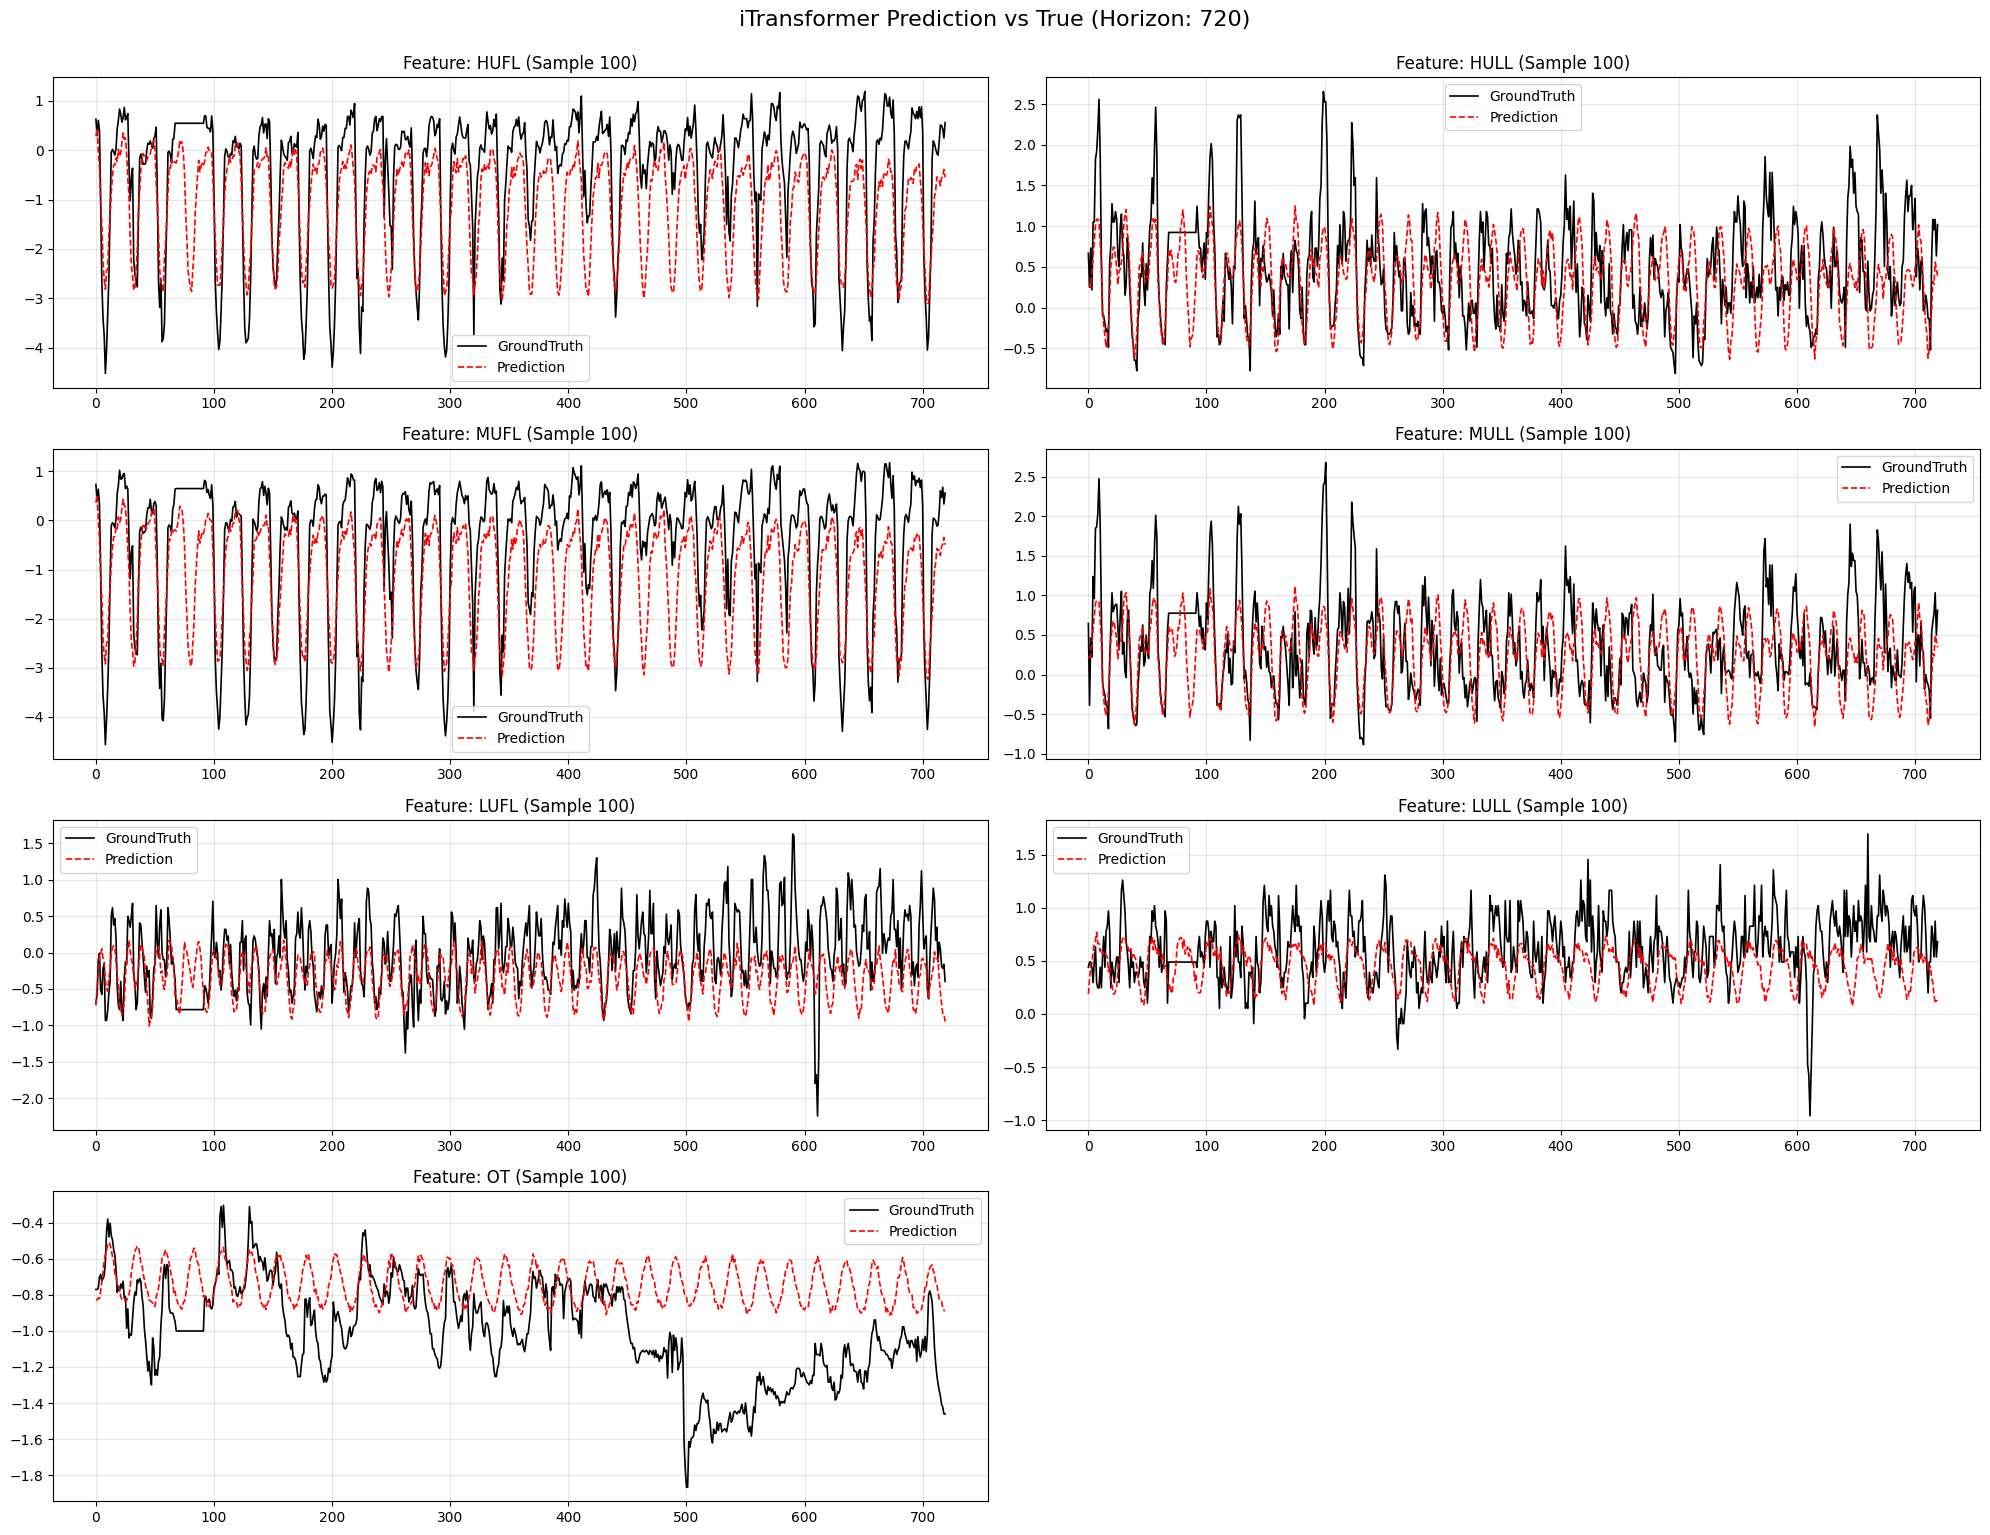

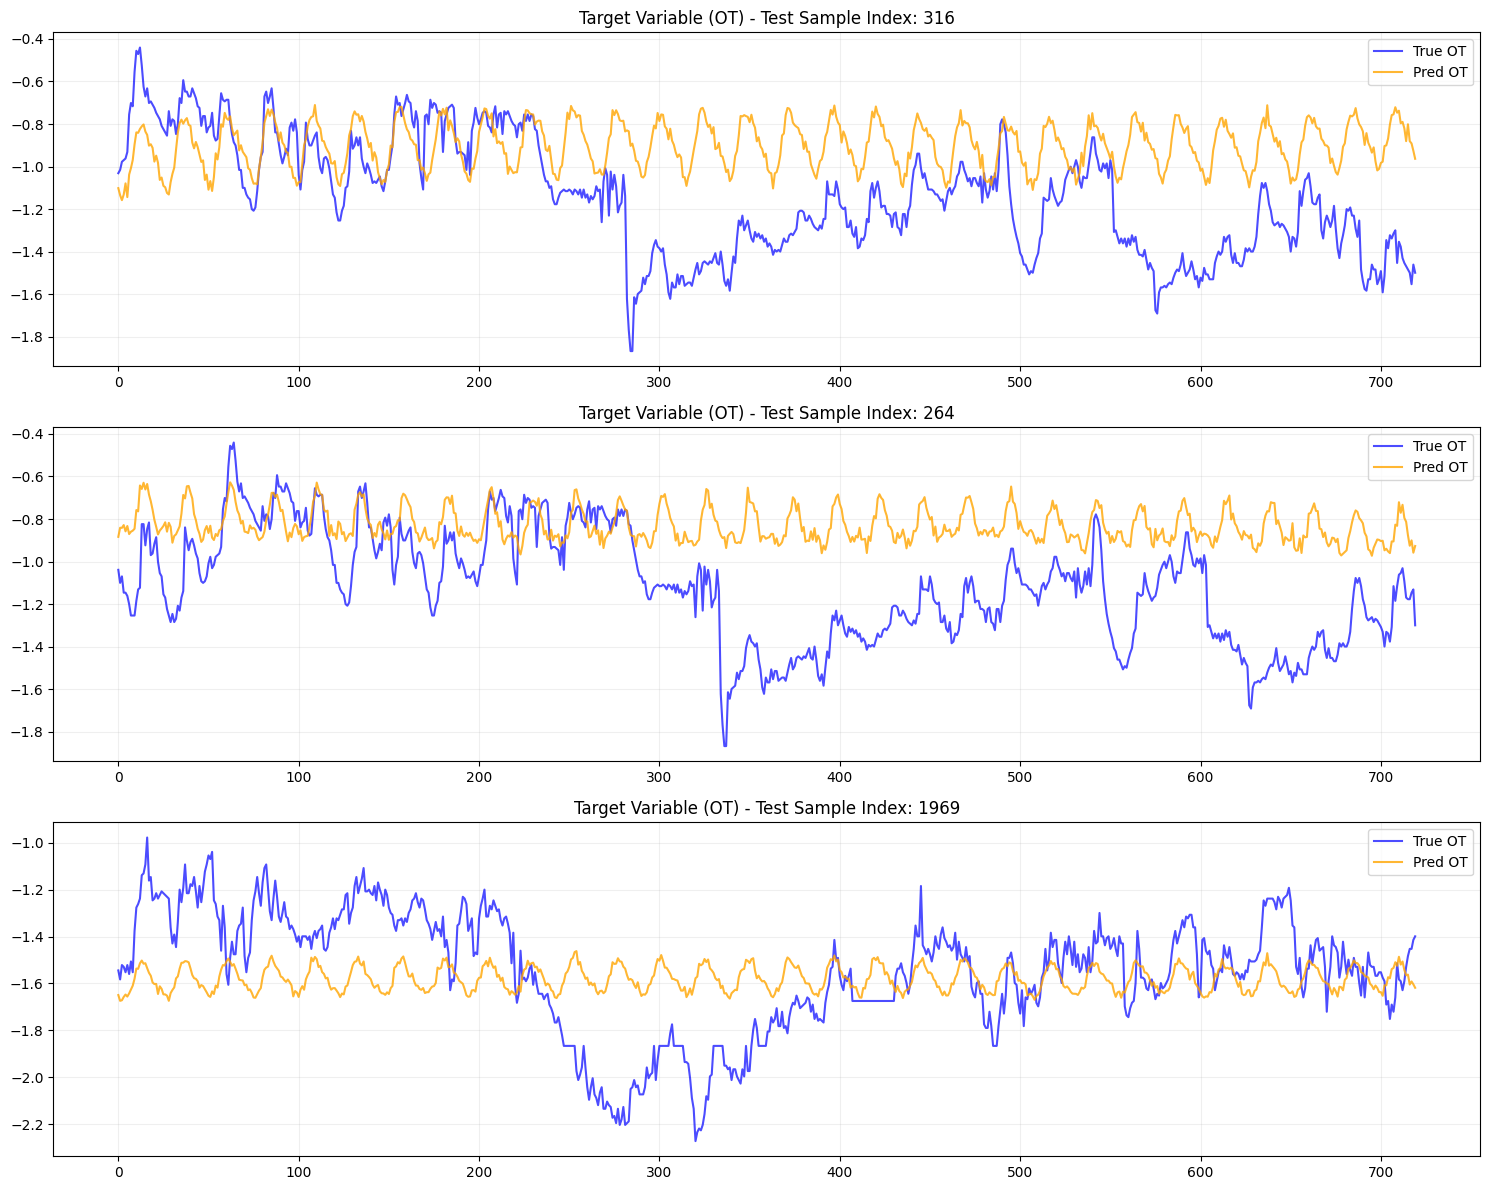

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import random

# 假设 preds 和 trues 已经加载完毕
# preds.shape: (2161, 720, 7)
# trues.shape: (2161, 720, 7)

# 设置变量名称（对应 ETTh1 的标准列名）
feature_names = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

def plot_prediction_comparison(sample_idx=0):
    """
    可视化指定样本的所有 7 个变量的预测对比
    """
    plt.figure(figsize=(20, 15))
    for i in range(7):
        plt.subplot(4, 2, i + 1)
        plt.plot(trues[sample_idx, :, i], label='GroundTruth', color='black', linewidth=1.2)
        plt.plot(preds[sample_idx, :, i], label='Prediction', color='red', linestyle='--', linewidth=1.2)
        plt.title(f'Feature: {feature_names[i]} (Sample {sample_idx})')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle(f"iTransformer Prediction vs True (Horizon: 720)", fontsize=16, y=1.02)
    plt.show()

def plot_target_only(feature_idx=-1, num_samples=3):
    """
    随机挑几个样本，只看目标变量 (OT) 的预测效果
    """
    plt.figure(figsize=(15, 4 * num_samples))
    indices = random.sample(range(len(preds)), num_samples)
    
    for i, idx in enumerate(indices):
        plt.subplot(num_samples, 1, i + 1)
        plt.plot(trues[idx, :, feature_idx], label='True OT', color='blue', alpha=0.7)
        plt.plot(preds[idx, :, feature_idx], label='Pred OT', color='orange', alpha=0.8)
        plt.title(f'Target Variable (OT) - Test Sample Index: {idx}')
        plt.legend()
        plt.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()

# --- 执行可视化 ---

# 1. 查看第 100 个样本的所有变量预测情况
plot_prediction_comparison(sample_idx=100)

# 2. 随机抽取 3 个样本查看目标列 OT 的拟合程度
plot_target_only(feature_idx=-1, num_samples=3)

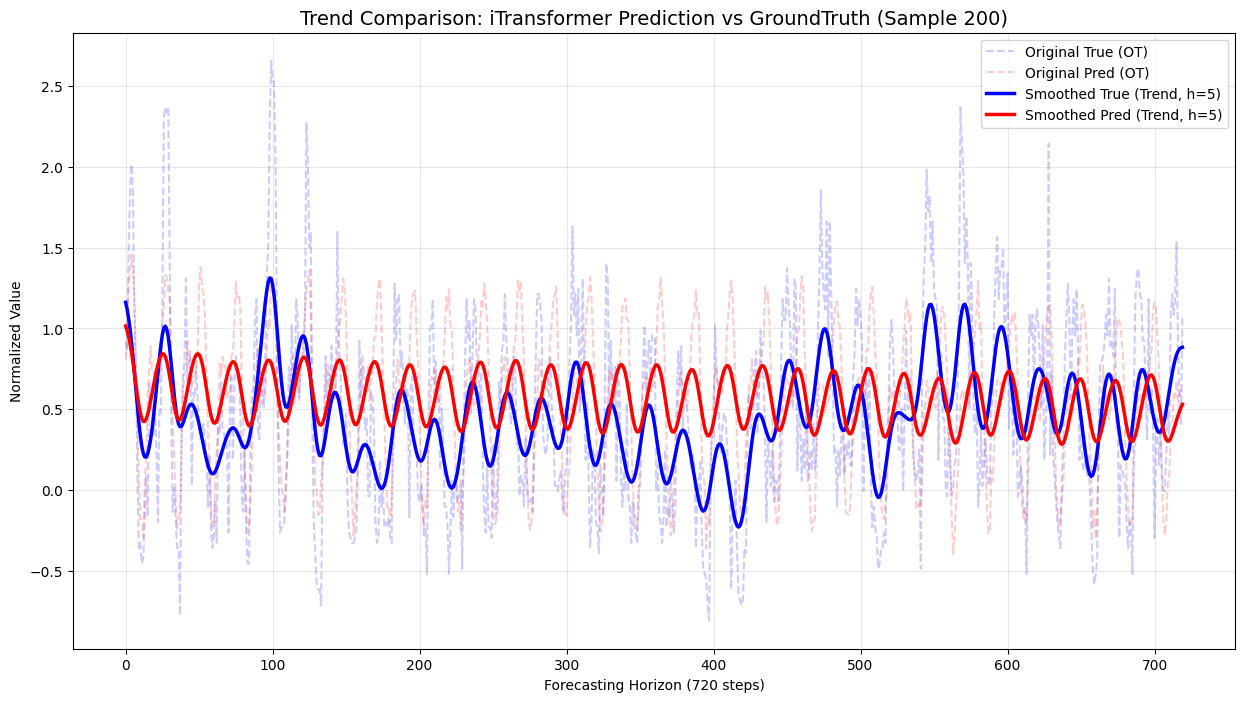

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定义高斯核平滑函数 (Nadaraya-Watson)
def gaussian_kernel_smoothing(data, bandwidth=15):
    n = len(data)
    smoothed = np.zeros(n)
    x = np.arange(n)
    for t in range(n):
        weights = np.exp(-0.5 * ((x - t) / bandwidth)**2)
        smoothed[t] = np.sum(weights * data) / np.sum(weights)
    return smoothed

# 2. 挑选样本 (假设 preds, trues 维度为 [2161, 720, 7])
sample_idx = 200
feature_idx = 1  # OT 目标列

true_series = trues[sample_idx, :, feature_idx]
pred_series = preds[sample_idx, :, feature_idx]

# 3. 分别进行核回归平滑 (带宽设为 15，提取主干趋势)
bandwidth = 5
true_smooth = gaussian_kernel_smoothing(true_series, bandwidth=bandwidth)
pred_smooth = gaussian_kernel_smoothing(pred_series, bandwidth=bandwidth)

# 4. 可视化比较
plt.figure(figsize=(15, 8))

# 绘制原始曲线（细虚线/浅色）
plt.plot(true_series, label='Original True (OT)', color='blue', alpha=0.2, linestyle='--')
plt.plot(pred_series, label='Original Pred (OT)', color='red', alpha=0.2, linestyle='--')

# 绘制平滑后的趋势曲线（实线/深色）
plt.plot(true_smooth, label=f'Smoothed True (Trend, h={bandwidth})', color='blue', linewidth=2.5)
plt.plot(pred_smooth, label=f'Smoothed Pred (Trend, h={bandwidth})', color='red', linewidth=2.5)

plt.title(f'Trend Comparison: iTransformer Prediction vs GroundTruth (Sample {sample_idx})', fontsize=14)
plt.xlabel('Forecasting Horizon (720 steps)')
plt.ylabel('Normalized Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
import torch
import torch.nn.functional as F
import numpy as np

# 1. 准备数据 (转换为 torch tensor)
# 假设 preds, trues 已经在你的内存中
p = torch.from_numpy(preds).float()
t = torch.from_numpy(trues).float()
B, L, D = p.shape

# 2. 定义解析导数矩阵预计算函数
def get_gaussian_deriv_kernels(L, h, device):
    grid = torch.arange(L).float().to(device)
    dist = grid.view(-1, 1) - grid.view(1, -1)
    dist_sq = dist**2
    K = torch.exp(-0.5 * dist_sq / (h**2))
    
    W = K / K.sum(dim=1, keepdim=True)
    
    # 一阶导核 (Velocity)
    K_prime = -(dist / (h**2)) * K
    W_prime = K_prime / K.sum(dim=1, keepdim=True)
    
    # 二阶导核 (Acceleration)
    K_double_prime = (dist_sq / (h**4) - 1 / (h**2)) * K
    W_double_prime = K_double_prime / K.sum(dim=1, keepdim=True)
    
    return W, W_prime, W_double_prime

# 3. 计算各个分量
h = 5.0 # pred_len 720 的 2% 左右
W, W1, W2 = get_gaussian_deriv_kernels(L, h, p.device)

# 提取特征
p_trend = torch.matmul(W, p)
t_trend = torch.matmul(W, t)
p_res = p - p_trend
t_res = t - t_trend
p_vel = torch.matmul(W1, p)
t_vel = torch.matmul(W1, t)
p_acc = torch.matmul(W2, p)
t_acc = torch.matmul(W2, t)

# 4. 统计数量级
results = {
    "Base MSE (Raw)": F.mse_loss(p, t).item(),
    "Base MAE (Raw)": F.l1_loss(p, t).item(),
    "Res MAE (Raw)": F.l1_loss(p_res, t_res).item(),
    "Trend MSE": F.l1_loss(p_trend, t_trend).item(),
    "Velocity MSE": F.l1_loss(p_vel, t_vel).item(),
    "Acceleration MSE": F.l1_loss(p_acc, t_acc).item()
}

print("--- 各个分量输出及数量级分析 ---")
for k, v in results.items():
    print(f"{k:<20}: {v:.10f}  (约 10^{int(np.floor(np.log10(v)) if v>0 else 0)})")

--- 各个分量输出及数量级分析 ---
Base MSE (Raw)      : 0.5215191841  (约 10^-1)
Base MAE (Raw)      : 0.5041032434  (约 10^-1)
Res MAE (Raw)       : 0.2942303717  (约 10^-1)
Trend MSE           : 0.3657565713  (约 10^-1)
Velocity MSE        : 0.0338836759  (约 10^-2)
Acceleration MSE    : 0.0078802714  (约 10^-3)


In [24]:
p_vel

tensor([[[-0.0660,  0.0852, -0.0659,  ..., -0.0134,  0.0907, -0.1222],
         [-0.0857,  0.0729, -0.0872,  ..., -0.0125,  0.0705, -0.1011],
         [-0.1057,  0.0611, -0.1088,  ..., -0.0128,  0.0519, -0.0816],
         ...,
         [ 0.1752,  0.0021,  0.1774,  ...,  0.0470, -0.0248,  0.0751],
         [ 0.1767,  0.0165,  0.1787,  ...,  0.0443, -0.0372,  0.0920],
         [ 0.1770,  0.0300,  0.1788,  ...,  0.0408, -0.0515,  0.1109]],

        [[-0.0981,  0.0895, -0.0998,  ..., -0.0222,  0.0750, -0.1215],
         [-0.1177,  0.0758, -0.1211,  ..., -0.0208,  0.0585, -0.0999],
         [-0.1359,  0.0624, -0.1405,  ..., -0.0206,  0.0437, -0.0798],
         ...,
         [ 0.1476,  0.0132,  0.1499,  ...,  0.0404, -0.0284,  0.0753],
         [ 0.1446,  0.0229,  0.1468,  ...,  0.0395, -0.0413,  0.0932],
         [ 0.1417,  0.0301,  0.1436,  ...,  0.0389, -0.0555,  0.1131]],

        [[-0.1445,  0.0815, -0.1467,  ..., -0.0321,  0.0619, -0.1194],
         [-0.1568,  0.0679, -0.1605,  ..., -0

In [19]:
p

tensor([[[-1.2401e-01,  4.4966e-01, -1.0752e-01,  ..., -1.0627e-01,
           7.5971e-01, -8.6038e-01],
         [-3.3072e-02,  5.3520e-01,  1.2026e-03,  ..., -2.3055e-01,
           7.7445e-01, -8.4252e-01],
         [ 1.9030e-01,  6.1553e-01,  2.4958e-01,  ..., -2.2681e-01,
           7.0342e-01, -8.4788e-01],
         ...,
         [-4.9248e-01, -3.8391e-01, -5.0574e-01,  ...,  1.9163e-02,
           5.3270e-01, -8.1527e-01],
         [-4.2342e-01, -6.8702e-02, -4.2938e-01,  ...,  1.3668e-02,
           6.0412e-01, -8.2746e-01],
         [-2.9404e-01,  1.9808e-01, -2.7179e-01,  ..., -7.9050e-02,
           6.1204e-01, -8.5119e-01]],

        [[-5.8410e-02,  5.8071e-01, -1.4393e-02,  ..., -1.8856e-01,
           7.0351e-01, -8.8087e-01],
         [ 3.3501e-02,  5.9538e-01,  8.5551e-02,  ..., -3.0611e-01,
           6.7353e-01, -8.6642e-01],
         [ 2.8914e-01,  5.9106e-01,  3.3977e-01,  ..., -2.2059e-01,
           6.2964e-01, -8.6160e-01],
         ...,
         [-3.7471e-01, -1